# Run this file in Google Colab
- Dont forget to select GPU in runtime

### Cat Vs Dog Image Classifier

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d anthonytherrien/dog-vs-cat

Dataset URL: https://www.kaggle.com/datasets/anthonytherrien/dog-vs-cat
License(s): CC-BY-SA-4.0
100% 360M/360M [00:02<00:00, 166MB/s]



In [ ]:
!unzip dog-vs-cat.zip

In [36]:
import tensorflow as tf
from keras import Sequential
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

from keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt
import seaborn as sns

___Load Data___

The data first has to be converted into keras.data.Dataset, for this we will use "image_dataset_from_directory" function

It creates a dataset by:
- Loading images from data folder
- Labelling them based on subfolder name (labels='inferred')
- Resizes them (since there can be images of different size in folder but we want same size for training, this enforces that size)
- Acts as generator. Since data can be huge and not fit in RAM, this function acts as generator, taking each batch in RAM using lazy loading

In [41]:
(train_data, val_data) = image_dataset_from_directory(
    directory = "animals",
    labels = 'inferred',
    label_mode = 'binary',
    batch_size = 32,
    seed = 42,
    validation_split = 0.2,
    subset = 'both',
    image_size = (256,256)
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Using 200 files for validation.


In [42]:
print(train_data)
for images, labels in train_data.take(1):
    # print(images)  #Get first batch of images
    # print(images[1]) #Get first images in respective batch
    print(images.shape)
    print(labels.shape)
    print(images.dtype)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
(32, 256, 256, 3)
(32, 1)
<dtype: 'float32'>


___Normalize pixels___

In [44]:
## check the range of pixels
for images, label in train_data.take(1):
    print(images.dtype)
    print("Min pixel: ", tf.reduce_min(images), "\nMax pixel", tf.reduce_max(images))

<dtype: 'float32'>
Min pixel:  tf.Tensor(0.0, shape=(), dtype=float32) 
Max pixel tf.Tensor(255.0, shape=(), dtype=float32)


In [45]:
## Normalize the images into range = [0,1]
train_data = train_data.map(lambda img, label: (img/255.0, label))
val_data = val_data.map(lambda img, label: (img/255.0, label))

In [46]:
## check the range of pixels
for images, label in train_data.take(1):
    print(images.dtype)
    print("Min pixel: ", tf.reduce_min(images), "\nMax pixel", tf.reduce_max(images))

<dtype: 'float32'>
Min pixel:  tf.Tensor(0.0, shape=(), dtype=float32) 
Max pixel tf.Tensor(1.0, shape=(), dtype=float32)


___Prepare and Train model___

In [50]:
model = Sequential()

model.add(Input(shape=(256,256,3)))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(filters=128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_data, epochs=10, validation_data=val_data)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 431ms/step - accuracy: 0.5825 - loss: 0.7524 - val_accuracy: 0.7450 - val_loss: 0.5338
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 386ms/step - accuracy: 0.8500 - loss: 0.3603 - val_accuracy: 0.8550 - val_loss: 0.3246
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.9312 - loss: 0.1909 - val_accuracy: 0.9150 - val_loss: 0.2511
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.9675 - loss: 0.1031 - val_accuracy: 0.8700 - val_loss: 0.3475
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.9875 - loss: 0.0534 - val_accuracy: 0.8750 - val_loss: 0.3725
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.9937 - loss: 0.0309 - val_accuracy: 0.8750 - val_loss: 0.3573
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.9875 - loss: 0.0326 - val_accuracy: 0.8700 - val_loss: 0.3210
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy:

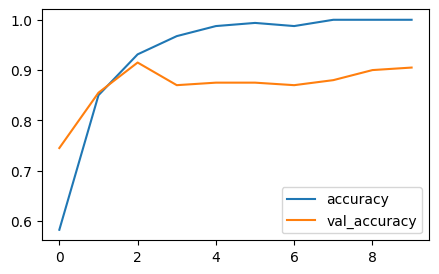

In [52]:
plt.figure(figsize=(5,3))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

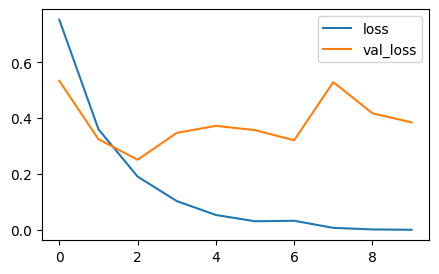

In [53]:
plt.figure(figsize=(5,3))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

___Fix Overfitting___

In [65]:
model_1 = Sequential()

model_1.add(Input(shape=(256,256,3)))
model_1.add(Conv2D(filters=64, kernel_size=(3,3), padding='valid', activation='relu'))
# model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model_1.add(Conv2D(filters=32, kernel_size=(3,3), padding='valid', activation='relu'))
# model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model_1.add(Conv2D(filters=16, kernel_size=(3,3), padding='valid', activation='relu'))
# model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model_1.add(Flatten())

model_1.add(Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2))
model_1.add(Dropout(0.1))
model_1.add(Dense(64, activation='relu',kernel_regularizer=tf.keras.regularizers.l2))
model_1.add(Dropout(0.1))
model_1.add(Dense(1, activation='sigmoid',kernel_regularizer=tf.keras.regularizers.l2))

model_1.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 125, 125, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │     1,843,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,876,529 (7.16 MB)

 Trainable params: 1,876,529 (7.16 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_1 = model_1.fit(train_data, epochs=10, validation_data=val_data)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - accuracy: 0.6263 - loss: 2.1345 - val_accuracy: 0.6400 - val_loss: 1.3573
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.7713 - loss: 1.1224 - val_accuracy: 0.7800 - val_loss: 0.9711
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.8650 - loss: 0.8687 - val_accuracy: 0.8100 - val_loss: 0.8589
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.9137 - loss: 0.6857 - val_accuracy: 0.9150 - val_loss: 0.6381
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.9463 - loss: 0.5265 - val_accuracy: 0.9300 - val_loss: 0.5315
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 339ms/step - accuracy: 0.9312 - loss: 0.4984 - val_accuracy: 0.9200 - val_loss: 0.5357
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step - accuracy: 0.9425 - loss: 0.4334 - val_accuracy: 0.9050 - val_loss: 0.5300
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.9712 - loss: 0.3414 - val_accuracy: 

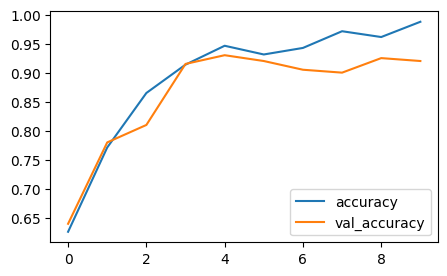

In [67]:
plt.figure(figsize=(5,3))
plt.plot(history_1.history['accuracy'], label='accuracy')
plt.plot(history_1.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

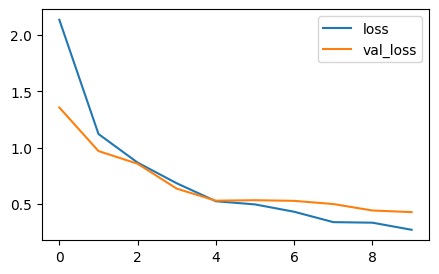

In [68]:
plt.figure(figsize=(5,3))
plt.plot(history_1.history['loss'], label='loss')
plt.plot(history_1.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

___Prediction on random images___

In [69]:
import cv2

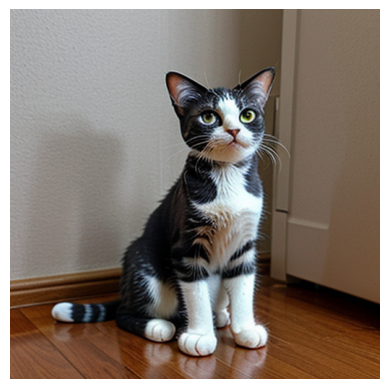

In [ ]:
img = cv2.imread('00001-4122619874.png')     #Give your path for test img
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis(False)
plt.show()

In [136]:
print(img.shape)
img = cv2.resize(img, (256,256))
img = img.reshape(1,256,256,3)
print(img.shape)

(512, 512, 3)
(1, 256, 256, 3)


In [137]:
#Normalize the image
img = tf.cast(img, tf.float32) / 255.0

In [138]:
model_1.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.00735306]], dtype=float32)

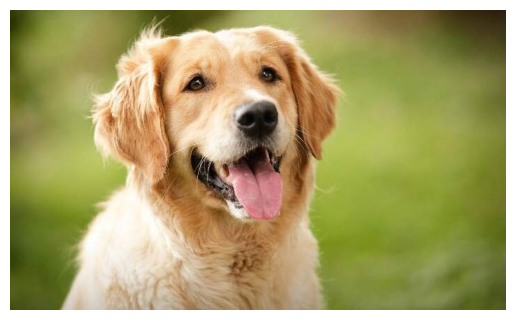

In [ ]:
img = cv2.imread('dog.jpg')                   #Give your path for test image 
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis(False)
plt.show()

In [140]:
print(img.shape)
img = cv2.resize(img, (256,256))
img = img.reshape(1,256,256,3)
print(img.shape)

(430, 710, 3)
(1, 256, 256, 3)


In [141]:
#Normalize the image
img = tf.cast(img, tf.float32) / 255.0

In [142]:
model_1.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.99995196]], dtype=float32)